# Olist E-Commerce — Exploratory Data Analysis

**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)
**Source of this data:** cleaned tables produced in Phase 1 of this project
(PostgreSQL, hosted on Neon) — see the `sql/` folder in this repository for
the full data-cleaning process (staging tables, type casting, deduplication,
constraints).

**Goal of this notebook:** explore the cleaned Olist data to understand order
volume and revenue trends, delivery performance, customer/seller geography,
product category popularity, and customer satisfaction (review scores) —
setting up the questions and features that the companion notebook
(`02_late_delivery_prediction.ipynb`) will use for a delivery-delay
prediction model.

**How to run this notebook on Kaggle:**
1. Create a new Kaggle Dataset containing the cleaned CSV files
   (`cleaned_customers.csv`, `cleaned_orders.csv`, `cleaned_order_items.csv`,
   `cleaned_order_payments.csv`, `cleaned_order_reviews.csv`,
   `cleaned_products.csv`, `cleaned_sellers.csv`,
   `cleaned_product_category_translation.csv`, and optionally
   `cleaned_geolocation.csv`).
2. Create a new Kaggle Notebook and attach that dataset ("Add Data").
3. Update the `DATA_DIR` path in the cell below to match your dataset's
   folder name (visible in the file browser on the right side of the
   Kaggle notebook editor).


## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.edgecolor"] = "#52514e"
plt.rcParams["axes.labelcolor"] = "#0b0b0b"
plt.rcParams["text.color"] = "#0b0b0b"
plt.rcParams["xtick.color"] = "#52514e"
plt.rcParams["ytick.color"] = "#52514e"

# Fixed categorical color order (colorblind-safe, validated palette)
COLORS = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100",
          "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE = COLORS[0]
sns.set_palette(COLORS)

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")


In [2]:
# Path to the folder containing the cleaned CSV files.
# On Kaggle this will look like: "/kaggle/input/<your-dataset-folder-name>/"
DATA_DIR = "/kaggle/input/olist-cleaned-data/"


## 2. Load the cleaned data

In [3]:
customers = pd.read_csv(f"{DATA_DIR}cleaned_customers.csv")
orders = pd.read_csv(f"{DATA_DIR}cleaned_orders.csv", parse_dates=[
    "order_purchase_timestamp", "order_approved_at",
    "order_delivered_carrier_date", "order_delivered_customer_date",
    "order_estimated_delivery_date"
])
order_items = pd.read_csv(f"{DATA_DIR}cleaned_order_items.csv", parse_dates=["shipping_limit_date"])
order_payments = pd.read_csv(f"{DATA_DIR}cleaned_order_payments.csv")
order_reviews = pd.read_csv(f"{DATA_DIR}cleaned_order_reviews.csv", parse_dates=[
    "review_creation_date", "review_answer_timestamp"
])
products = pd.read_csv(f"{DATA_DIR}cleaned_products.csv")
sellers = pd.read_csv(f"{DATA_DIR}cleaned_sellers.csv")
category_translation = pd.read_csv(f"{DATA_DIR}cleaned_product_category_translation.csv")

print("customers:         ", customers.shape)
print("orders:             ", orders.shape)
print("order_items:        ", order_items.shape)
print("order_payments:     ", order_payments.shape)
print("order_reviews:      ", order_reviews.shape)
print("products:           ", products.shape)
print("sellers:            ", sellers.shape)
print("category_translation:", category_translation.shape)


customers:          (99441, 5)
orders:              (99441, 8)
order_items:         (112650, 7)
order_payments:      (103886, 5)
order_reviews:       (99224, 7)
products:            (32951, 9)
sellers:             (3095, 4)
category_translation: (71, 2)


**Note on data types:** all 9 tables were already cleaned and correctly
typed in PostgreSQL (Phase 1), so the CSV export contains valid numbers and
timestamps — the only extra step needed here is telling `pandas.read_csv`
which columns to parse as dates, since a CSV file has no native date type.

## 3. Data overview

In [4]:
orders.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26


In [5]:
orders.info()


<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  str           
 1   customer_id                    99441 non-null  str           
 2   order_status                   99441 non-null  str           
 3   order_purchase_timestamp       99441 non-null  datetime64[us]
 4   order_approved_at              99281 non-null  datetime64[us]
 5   order_delivered_carrier_date   97658 non-null  datetime64[us]
 6   order_delivered_customer_date  96476 non-null  datetime64[us]
 7   order_estimated_delivery_date  99441 non-null  datetime64[us]
dtypes: datetime64[us](5), str(3)
memory usage: 6.1 MB


In [6]:
# Missing values in the orders table (some are expected: e.g. orders that
# have not been delivered yet legitimately have no delivery date)
orders.isna().sum()


order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

## 4. Order status breakdown

What share of orders are actually delivered, versus canceled, shipped, etc.?

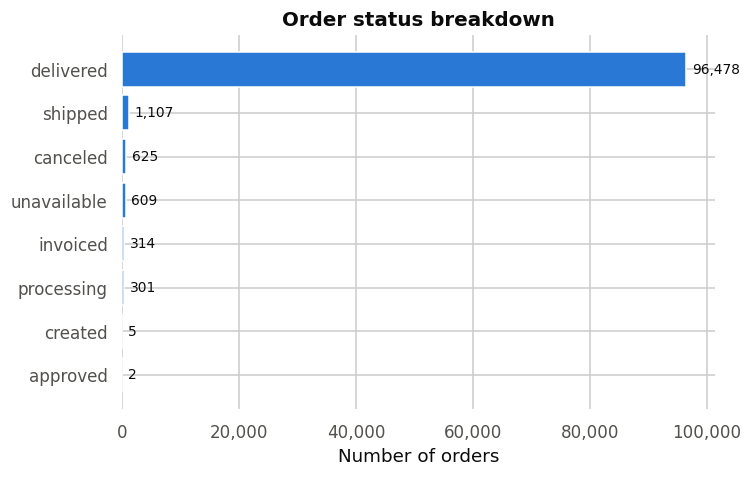

97.0% of all orders were successfully delivered.


In [7]:
status_counts = orders["order_status"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.barh(status_counts.index[::-1], status_counts.values[::-1], color=BLUE)
ax.set_xlabel("Number of orders")
ax.set_title("Order status breakdown", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, value in zip(bars, status_counts.values[::-1]):
    ax.text(bar.get_width() + max(status_counts.values) * 0.01, bar.get_y() + bar.get_height() / 2,
            f"{value:,}", va="center", fontsize=9, color="#0b0b0b")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print(f"{status_counts['delivered'] / status_counts.sum() * 100:.1f}% of all orders were successfully delivered.")


## 5. Monthly revenue trend

Total payment value per month, based on order purchase date.

**Important caveat:** the last two months in the dataset (September and
October 2018) show a sharp, artificial drop — this is a known data cutoff
in the Olist dataset (those months are almost empty), not an actual
collapse in sales. They are excluded from the trend line below to avoid a
misleading visual, but shown as a separate note.

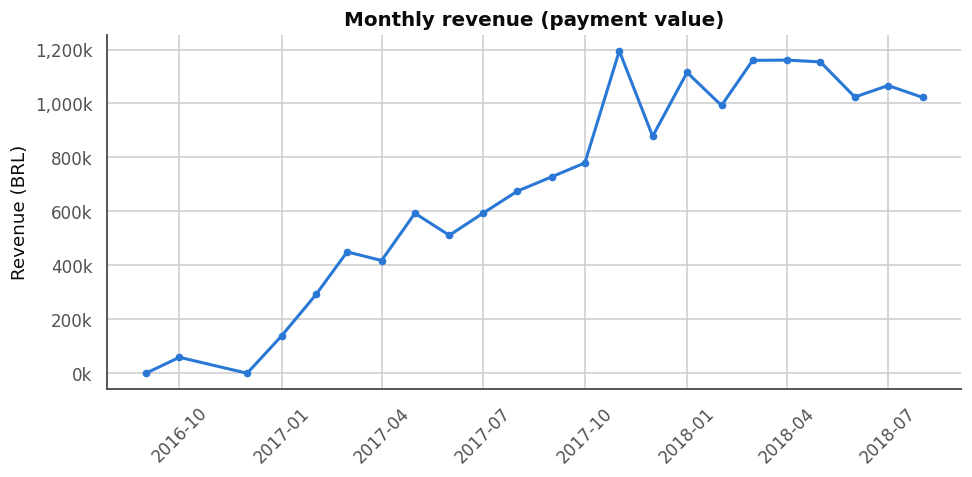

Excluded as incomplete (data cutoff):
order_month
2018-09-01   4,439.54
2018-10-01     589.67
Name: payment_value, dtype: float64


In [8]:
orders_payments = orders.merge(order_payments, on="order_id")
orders_payments["order_month"] = orders_payments["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

monthly_revenue = orders_payments.groupby("order_month")["payment_value"].sum().sort_index()

# The last two months are known to be incomplete in this dataset
cutoff = pd.Timestamp("2018-09-01")
monthly_revenue_complete = monthly_revenue[monthly_revenue.index < cutoff]

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(monthly_revenue_complete.index, monthly_revenue_complete.values,
        color=BLUE, linewidth=2, marker="o", markersize=4)
ax.set_title("Monthly revenue (payment value)", fontsize=13, fontweight="bold")
ax.set_ylabel("Revenue (BRL)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x/1000:,.0f}k"))
ax.set_xlabel("")
sns.despine()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Excluded as incomplete (data cutoff):")
print(monthly_revenue[monthly_revenue.index >= cutoff])


## 6. Top 10 best-selling product categories

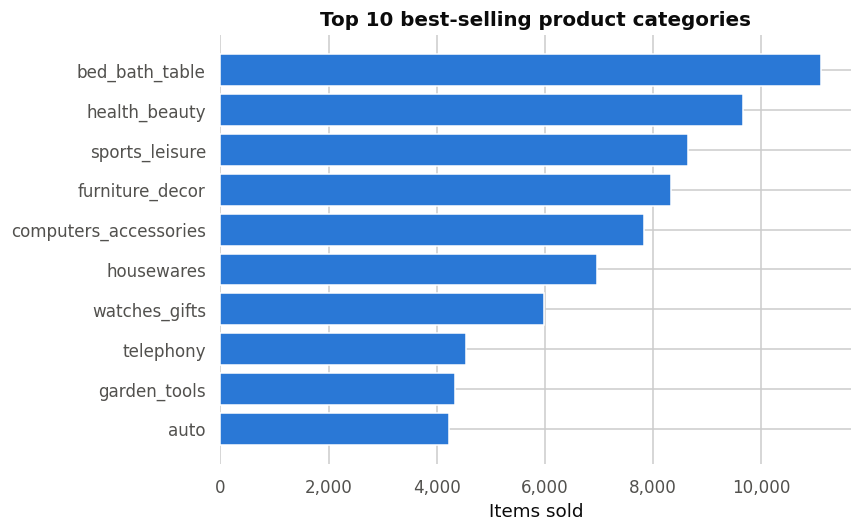

In [9]:
items_products = order_items.merge(products, on="product_id").merge(
    category_translation, on="product_category_name", how="left"
)

top_categories = (
    items_products["product_category_name_english"]
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(top_categories.index, top_categories.values, color=BLUE)
ax.set_xlabel("Items sold")
ax.set_title("Top 10 best-selling product categories", fontsize=13, fontweight="bold")
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## 7. Payment type distribution

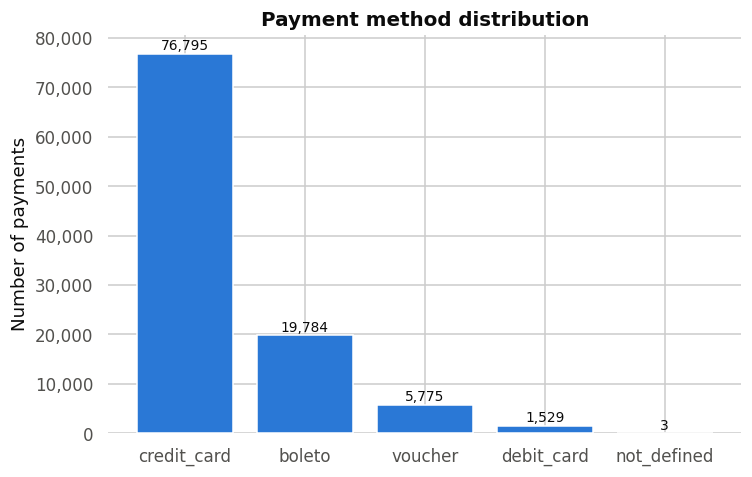

73.9% of payments are made by credit card.


In [10]:
payment_type_counts = order_payments["payment_type"].value_counts()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(payment_type_counts.index, payment_type_counts.values, color=BLUE)
ax.set_ylabel("Number of payments")
ax.set_title("Payment method distribution", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, value in zip(bars, payment_type_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(payment_type_counts.values) * 0.01,
            f"{value:,}", ha="center", fontsize=9, color="#0b0b0b")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

print(f"{payment_type_counts['credit_card'] / payment_type_counts.sum() * 100:.1f}% of payments are made by credit card.")


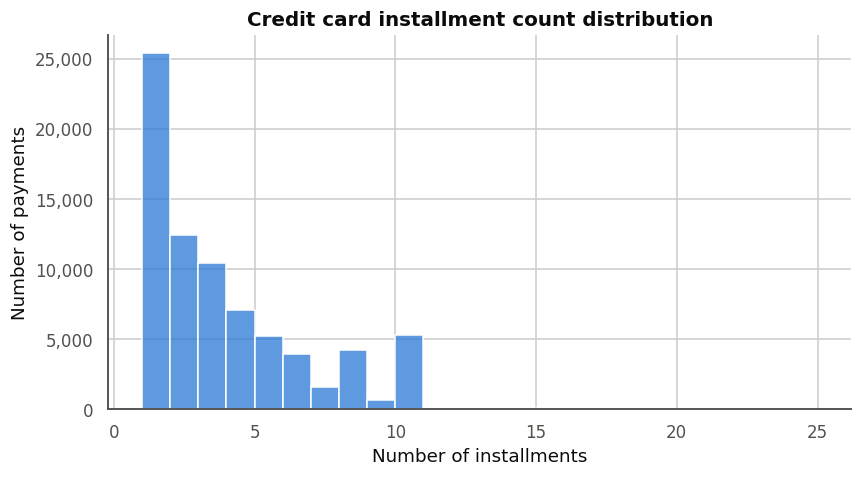

In [11]:
# Distribution of installment counts, credit card payments only
credit_card = order_payments[order_payments["payment_type"] == "credit_card"]

fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(credit_card["payment_installments"], bins=range(1, 26), color=BLUE, ax=ax)
ax.set_xlabel("Number of installments")
ax.set_ylabel("Number of payments")
ax.set_title("Credit card installment count distribution", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
sns.despine()
plt.tight_layout()
plt.show()


## 8. Delivery performance by state

Average delivery time (in days), for the 10 states with the most orders.
Only delivered orders are included, since a delivery time cannot be
computed otherwise.

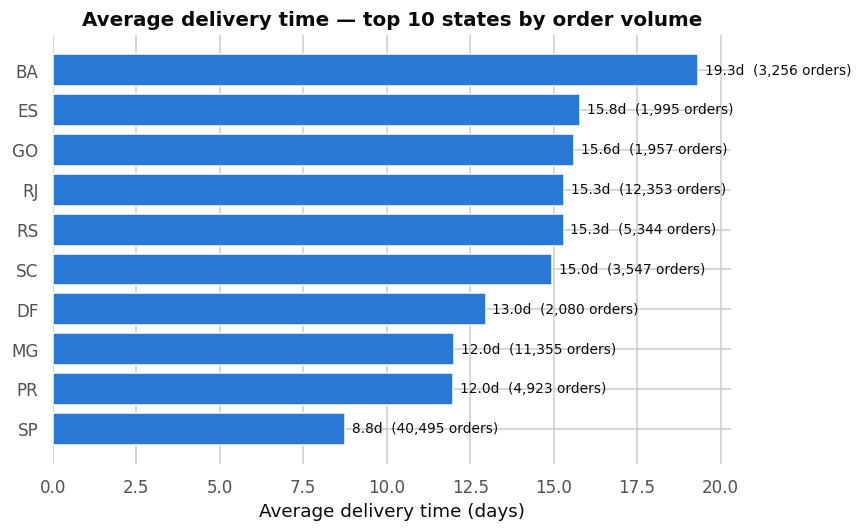

In [12]:
orders_customers = orders.merge(customers, on="customer_id")
delivered = orders_customers[orders_customers["order_delivered_customer_date"].notna()].copy()
delivered["delivery_days"] = (
    delivered["order_delivered_customer_date"] - delivered["order_purchase_timestamp"]
).dt.total_seconds() / 86400

state_summary = (
    delivered.groupby("customer_state")
    .agg(avg_delivery_days=("delivery_days", "mean"), total_orders=("order_id", "count"))
    .sort_values("total_orders", ascending=False)
    .head(10)
    .sort_values("avg_delivery_days")
)

fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(state_summary.index, state_summary["avg_delivery_days"], color=BLUE)
ax.set_xlabel("Average delivery time (days)")
ax.set_title("Average delivery time — top 10 states by order volume", fontsize=13, fontweight="bold")
for i, (days, orders_n) in enumerate(zip(state_summary["avg_delivery_days"], state_summary["total_orders"])):
    ax.text(days + 0.2, i, f"{days:.1f}d  ({orders_n:,} orders)", va="center", fontsize=9, color="#0b0b0b")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## 9. Customer review scores

How satisfied are customers overall, and is there a relationship between
delivery time and review score?

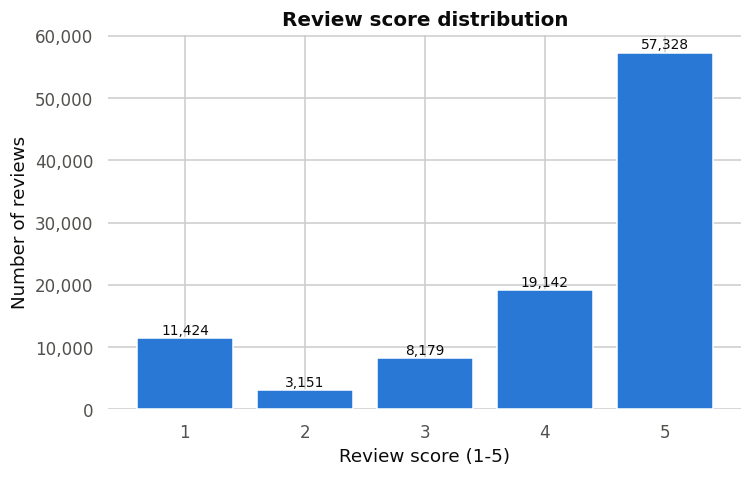

Average review score: 4.09 / 5
77.1% of reviews are 4 or 5 stars.


In [13]:
review_counts = order_reviews["review_score"].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(review_counts.index.astype(str), review_counts.values, color=BLUE)
ax.set_xlabel("Review score (1-5)")
ax.set_ylabel("Number of reviews")
ax.set_title("Review score distribution", fontsize=13, fontweight="bold")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
for bar, value in zip(bars, review_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + max(review_counts.values) * 0.01,
            f"{value:,}", ha="center", fontsize=9, color="#0b0b0b")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

avg_score = (order_reviews["review_score"] * review_counts.reindex(order_reviews["review_score"]).values).sum()
print(f"Average review score: {order_reviews['review_score'].mean():.2f} / 5")
print(f"{(order_reviews['review_score'] >= 4).mean() * 100:.1f}% of reviews are 4 or 5 stars.")


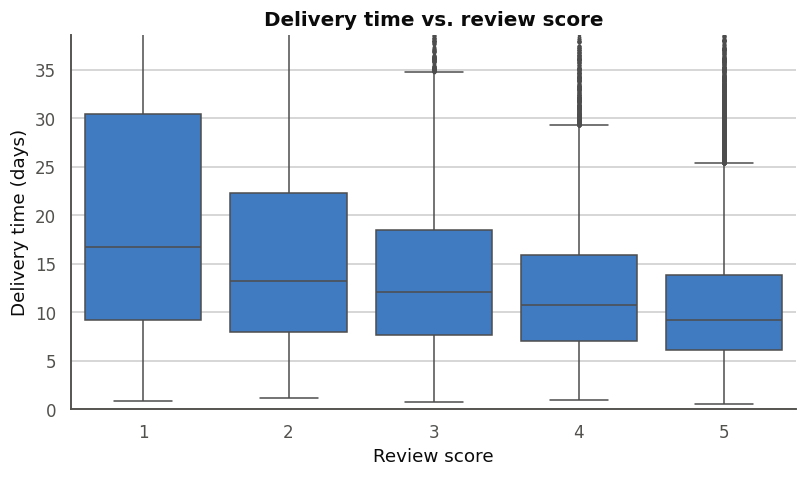

Correlation between delivery time and review score: -0.33
A negative correlation confirms the intuitive pattern: longer deliveries tend to get lower scores.


In [14]:
reviews_delivery = delivered.merge(
    order_reviews[["order_id", "review_score"]], on="order_id"
)

fig, ax = plt.subplots(figsize=(7.5, 4.5))
sns.boxplot(
    data=reviews_delivery, x="review_score", y="delivery_days",
    color=BLUE, fliersize=1.5, ax=ax
)
ax.set_ylim(0, reviews_delivery["delivery_days"].quantile(0.98))
ax.set_xlabel("Review score")
ax.set_ylabel("Delivery time (days)")
ax.set_title("Delivery time vs. review score", fontsize=13, fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

correlation = reviews_delivery["delivery_days"].corr(reviews_delivery["review_score"])
print(f"Correlation between delivery time and review score: {correlation:.2f}")
print("A negative correlation confirms the intuitive pattern: longer deliveries tend to get lower scores.")


## 10. Seller geography — where do sellers ship from?

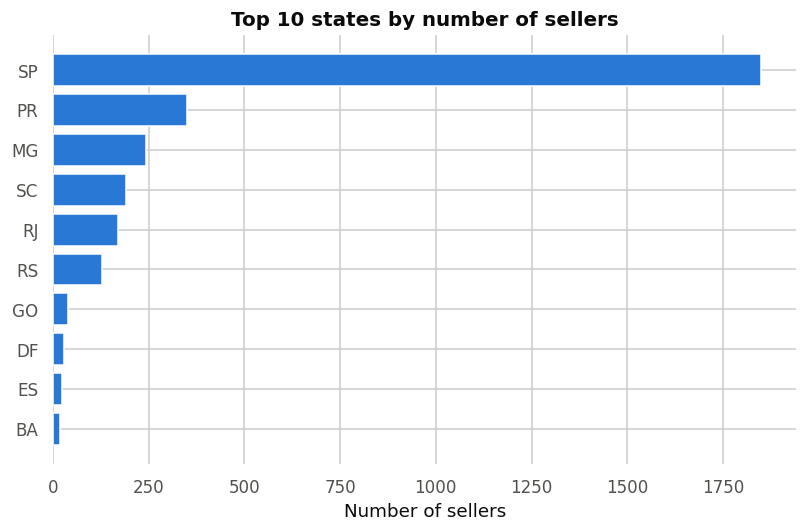

In [15]:
seller_state_counts = sellers["seller_state"].value_counts().head(10).sort_values()

fig, ax = plt.subplots(figsize=(7.5, 5))
ax.barh(seller_state_counts.index, seller_state_counts.values, color=BLUE)
ax.set_xlabel("Number of sellers")
ax.set_title("Top 10 states by number of sellers", fontsize=13, fontweight="bold")
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()


## 11. Key takeaways

- The large majority of orders reach the "delivered" status successfully;
  cancellations and unavailable orders are a small minority.
- Revenue grew steadily from late 2016 through 2018, with the well-known
  exception of the final two months of the dataset (an incomplete data
  cutoff, not a real drop).
- **bed_bath_table**, **health_beauty**, and **sports_leisure** are the
  best-selling product categories.
- Credit card is by far the dominant payment method, and installment
  payments are common.
- Delivery time varies substantially by state: customers in remote
  northern states (e.g. RR, AP, AM) wait noticeably longer than customers
  in São Paulo (SP), which also has the highest order volume.
- There is a clear negative relationship between delivery time and review
  score — slower deliveries are associated with lower customer satisfaction.
- Sellers are heavily concentrated in a handful of states (led by São
  Paulo), which likely explains part of the regional delivery-time gap.

These findings — especially the delivery-time and review-score patterns —
motivate the delivery-delay prediction task in the companion notebook,
`02_late_delivery_prediction.ipynb`.


## 12. Interactive dashboard

*(Placeholder — to be completed after the Power BI dashboard for this
project is built.)*

A companion Power BI dashboard was built on top of this same cleaned data,
covering revenue trends, delivery performance, and category-level KPIs
interactively. A screenshot will be added here, with a link to the `.pbix`
file in the `powerbi/` folder of this repository.
